## 1. Import Libraries

In [108]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


## 2. Load Cleaned Dataset

In [109]:
df=pd.read_csv("/Users/siddharthkushwaha/Desktop/CodeSoft/CodeSoft_Task2/Cleaned_online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 3. Understand the Dataset

In [110]:
df.shape

(401564, 8)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401564 entries, 0 to 401563
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401564 non-null  object 
 1   StockCode    401564 non-null  object 
 2   Description  401564 non-null  object 
 3   Quantity     401564 non-null  int64  
 4   InvoiceDate  401564 non-null  object 
 5   UnitPrice    401564 non-null  float64
 6   CustomerID   401564 non-null  int64  
 7   Country      401564 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 24.5+ MB


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401564 entries, 0 to 401563
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401564 non-null  object 
 1   StockCode    401564 non-null  object 
 2   Description  401564 non-null  object 
 3   Quantity     401564 non-null  int64  
 4   InvoiceDate  401564 non-null  object 
 5   UnitPrice    401564 non-null  float64
 6   CustomerID   401564 non-null  int64  
 7   Country      401564 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 24.5+ MB


In [113]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

## 4. Descriptive Statistics

In [114]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,401564.000000,401564.000000,401564.000000
mean,12.149911,3.474410,15281.266797
std,249.512649,69.767501,1713.978947
min,-80995.000000,0.001000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16788.000000
max,80995.000000,38970.000000,18287.000000


#### For categorical columns:

In [115]:
df.describe(include="object")

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,401564,401564,401564,401564,401564
unique,22186,3684,3896,20456,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-11-14 15:27:00,United Kingdom
freq,542,2065,2058,543,356704


## 5. Create Total Sales

In [116]:
df["TotalSales"]=df["Quantity"]*df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


#### Check total revenue:

In [117]:
df["TotalSales"].sum()

np.float64(8278519.424000001)

## 6. Sales Distribution

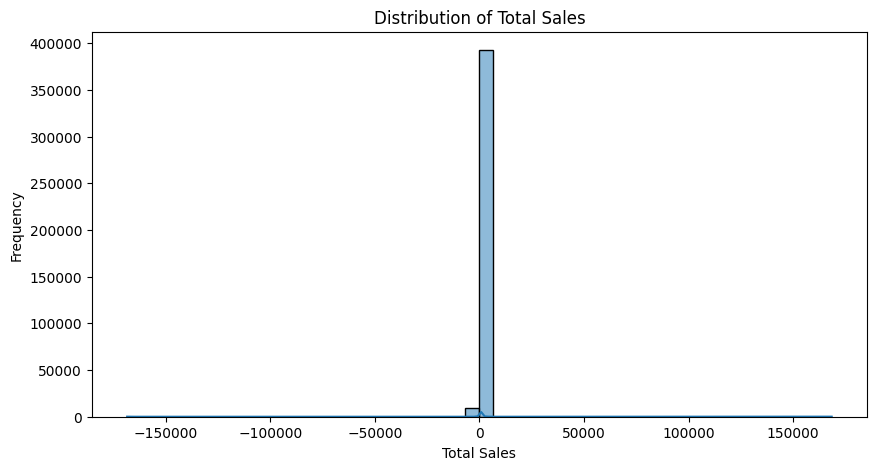

In [118]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalSales"],bins=50,kde=True)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

## 7. Quantity Distribution 

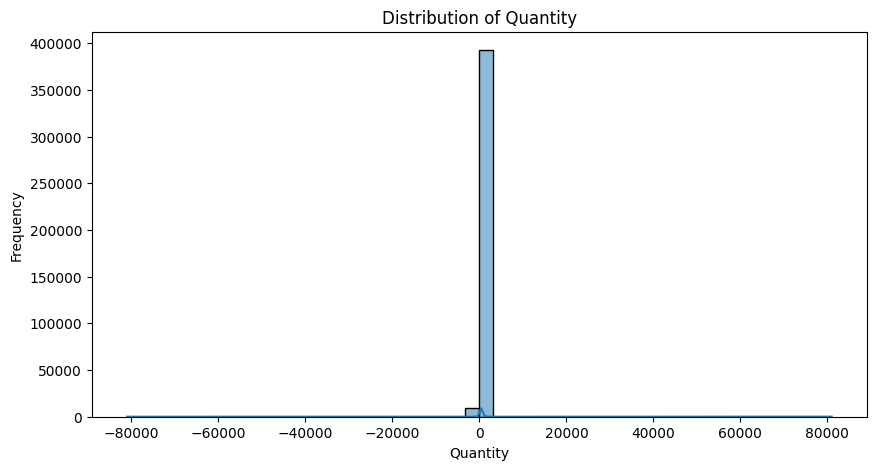

In [119]:
plt.figure(figsize=(10,5))

sns.histplot(df["Quantity"],bins=50,kde=True)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

## 8. Unit Price Distribution


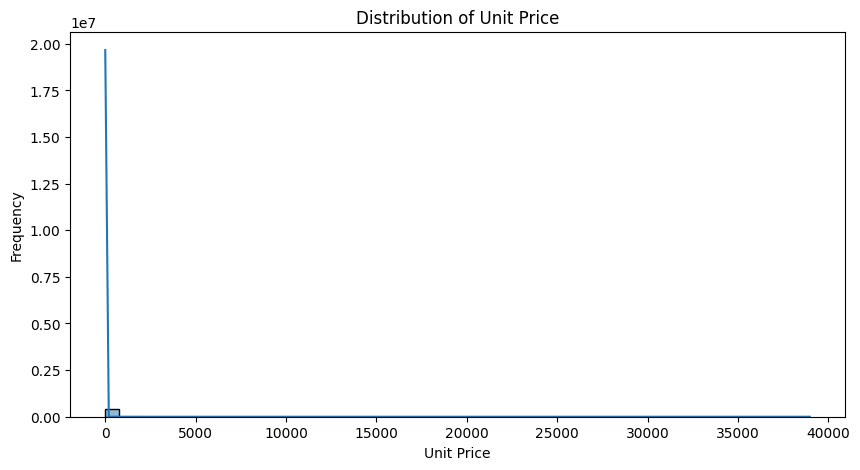

In [120]:
plt.figure(figsize=(10,5))

sns.histplot(df["UnitPrice"],bins=50,kde=True)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

## 9. Top Countries by Number of Transactions

In [121]:
country_counts = df["Country"].value_counts().head(10)

country_counts

Country
United Kingdom    356704
Germany             9478
France              8474
EIRE                7473
Spain               2527
Netherlands         2367
Belgium             2069
Switzerland         1876
Portugal            1471
Australia           1255
Name: count, dtype: int64

### Visualize:

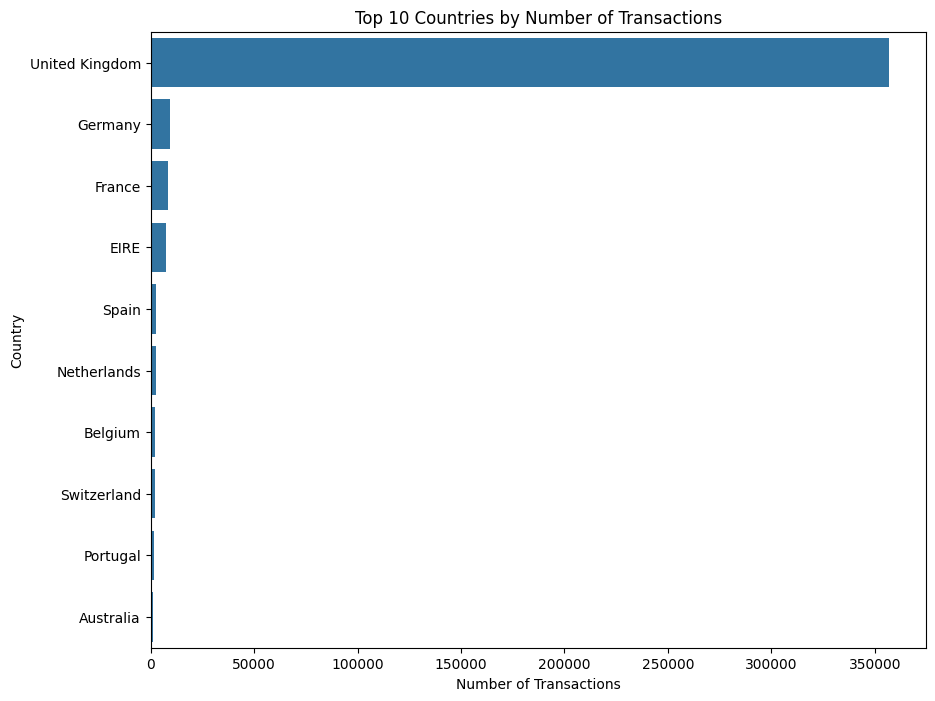

In [122]:
plt.figure(figsize=(10,8))

sns.barplot(x=country_counts.values,y=country_counts.index)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.show()

### 10. Top-Selling Products

In [123]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: Quantity, dtype: int64

### Visualize:

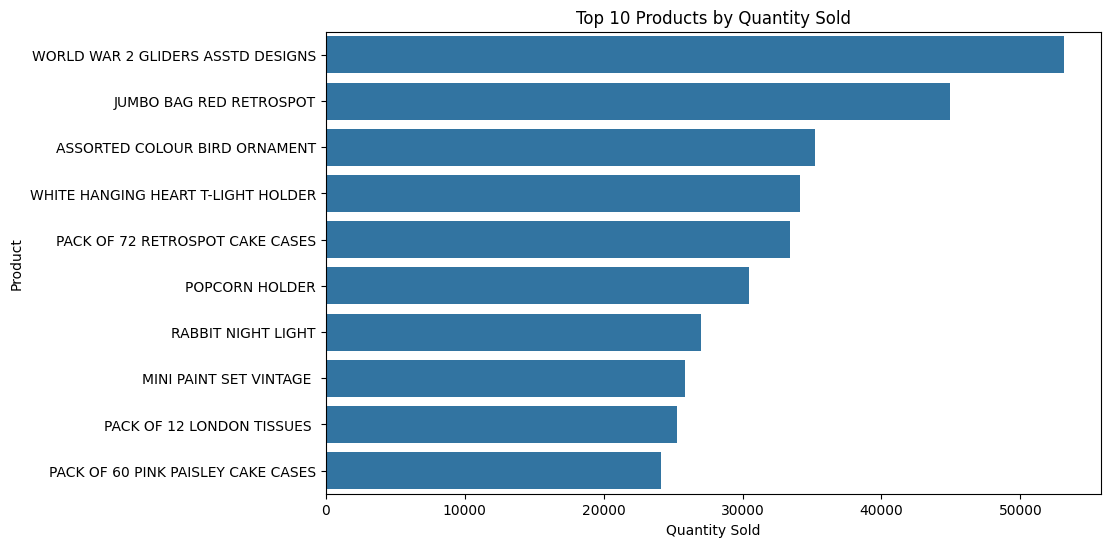

In [124]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

## 11. Top Products by Revenue

In [125]:
top_revenue_products = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_products

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalSales, dtype: float64

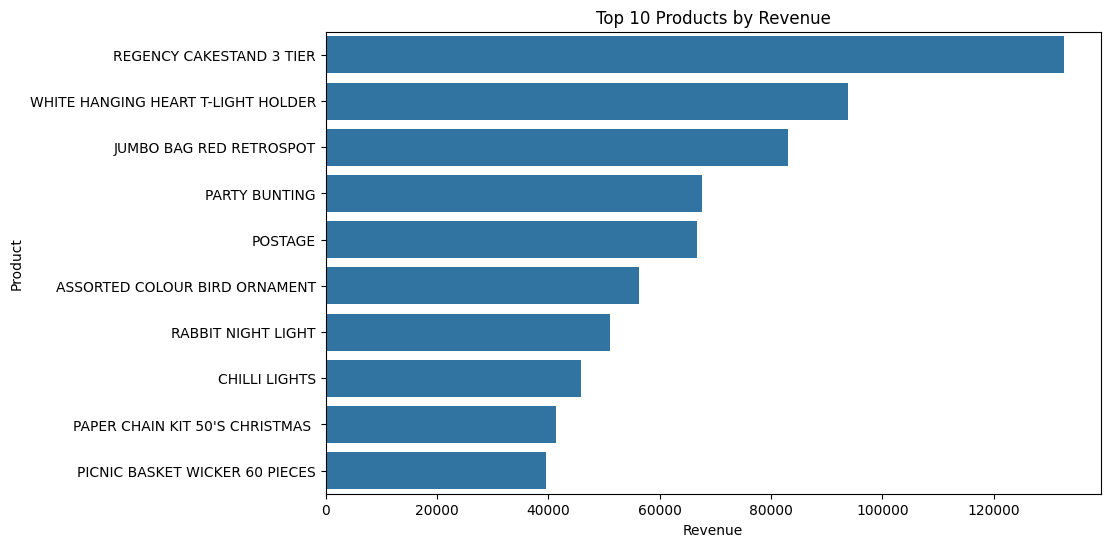

In [126]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_revenue_products.values,
    y=top_revenue_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

## 12. Monthly Sales Trend
### First convert the date:

In [127]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

### Create month

In [128]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

### Calculate monthly revenue: 

In [129]:
monthly_sales = (df.groupby("Month")["TotalSales"].sum())

monthly_sales

Month
2010-12     552372.860
2011-01     473731.900
2011-02     435534.070
2011-03     578576.210
2011-04     425222.671
2011-05     647011.670
2011-06     606862.520
2011-07     573112.321
2011-08     615078.090
2011-09     929356.232
2011-10     973306.380
2011-11    1126815.070
2011-12     341539.430
Freq: M, Name: TotalSales, dtype: float64

### PLOT

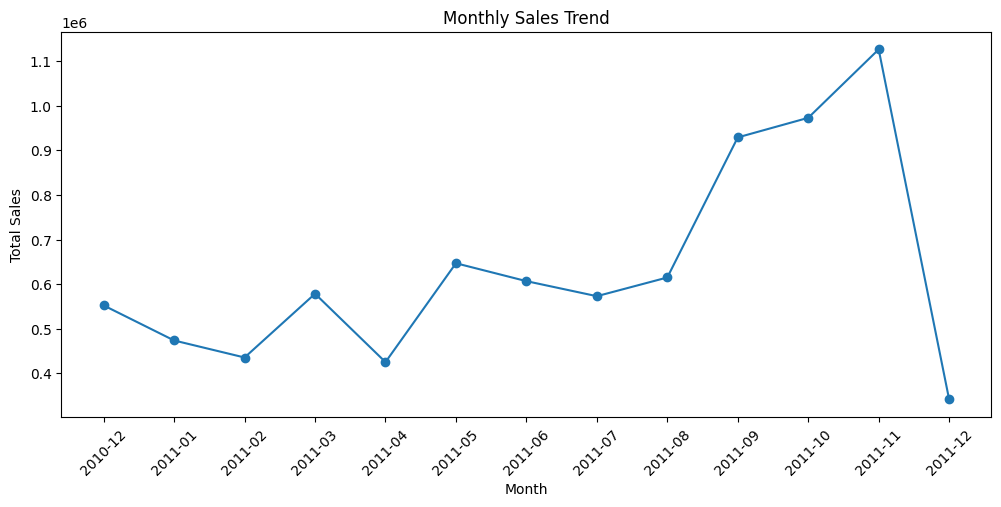

In [130]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

## 13. Sales by Country

In [131]:
country_sales = (df.groupby("Country")["TotalSales"].sum()
    .sort_values(ascending=False).head(10))

country_sales

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: TotalSales, dtype: float64

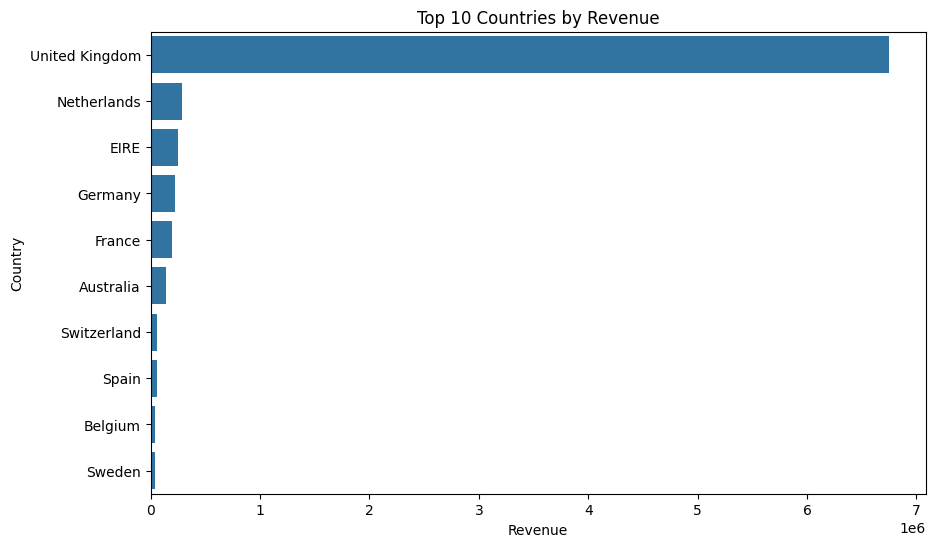

In [132]:
plt.figure(figsize=(10, 6))

sns.barplot(x=country_sales.values,y=country_sales.index)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

## 14. Relationship Between Quantity and Sales

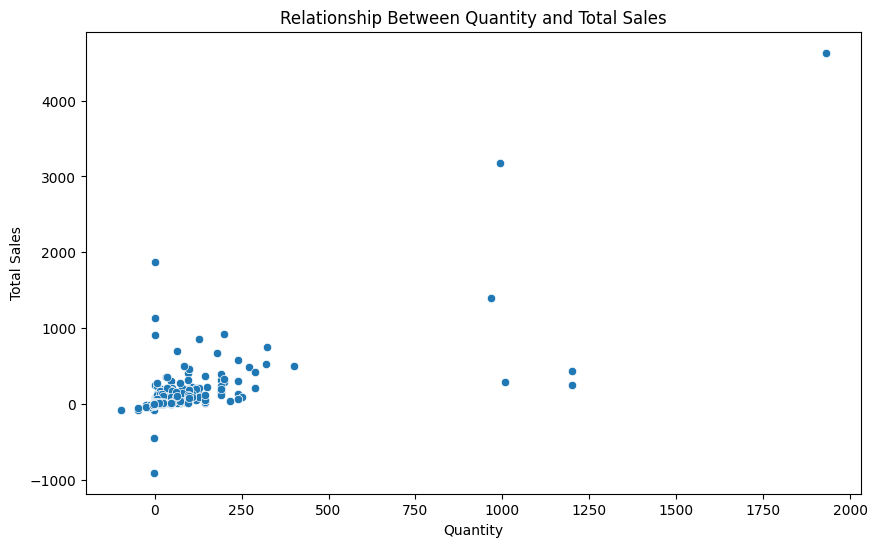

In [133]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df.sample(5000),x="Quantity",y="TotalSales")

plt.title("Relationship Between Quantity and Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()

## 15. Correlation Analysis

Select numerical columns:

In [134]:
numeric_columns = ["Quantity","UnitPrice","TotalSales"]

correlation = df[numeric_columns].corr()

correlation

,Quantity,UnitPrice,TotalSales
Quantity,1.000000,-0.001241,0.919011
UnitPrice,-0.001241,1.000000,-0.129311
TotalSales,0.919011,-0.129311,1.000000


### Heatmap:

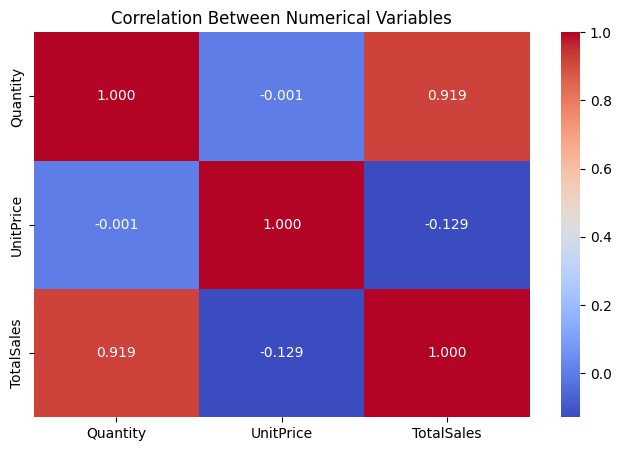

In [135]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".3f")

plt.title("Correlation Between Numerical Variables")

plt.show()

## 16. Detect Outliers — Quantity

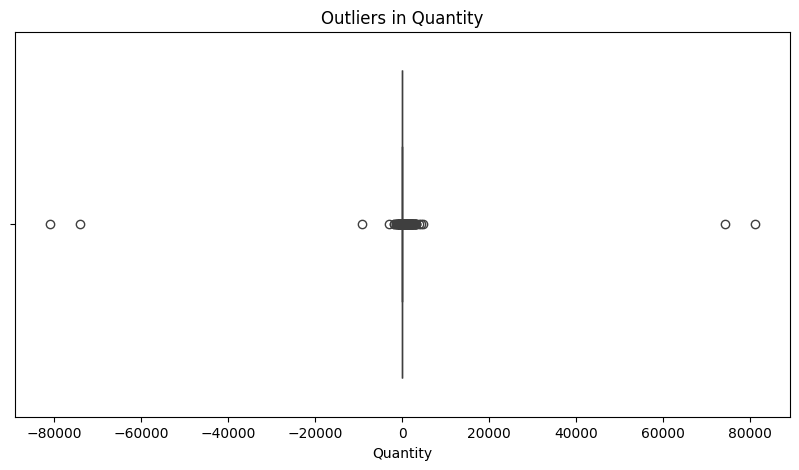

In [136]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Quantity"])

plt.title("Outliers in Quantity")
plt.xlabel("Quantity")

plt.show()

In [137]:
df["Quantity"].describe()

count    401564.000000
mean         12.149911
std         249.512649
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

## 17. Detect Outliers — Unit Price

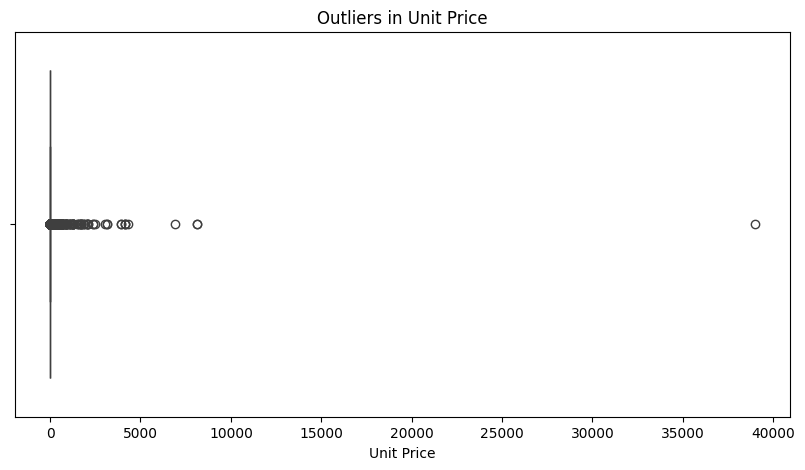

In [138]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["UnitPrice"])

plt.title("Outliers in Unit Price")
plt.xlabel("Unit Price")

plt.show()

### 18. Detect Outliers Using IQR

For Quantity:

In [139]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_quantity = df[(df["Quantity"] < lower_bound) |
      (df["Quantity"] > upper_bound)]

outliers_quantity.shape

(26637, 10)

### For Unit Price:

In [140]:
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_price = df[
    (df["UnitPrice"] < lower_bound) |
    (df["UnitPrice"] > upper_bound)]

outliers_price.shape

(35802, 10)

## 19. Business Questions

Now the important part of EDA: use statistics to answer business questions.

### Q1. What is the total revenue?

In [141]:
total_revenue = df["TotalSales"].sum()

total_revenue

np.float64(8278519.424000001)

### Q2. Which country generates the highest revenue?

In [142]:
df.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: TotalSales, dtype: float64

### Q3. Which product sells the most?

In [143]:
df.groupby("Description")["Quantity"].sum().sort_values(
    ascending=False
).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: Quantity, dtype: int64

### Q4. Which product generates the highest revenue?

In [144]:
df.groupby("Description")["TotalSales"].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalSales, dtype: float64

### Q5. Which month had the highest sales?

In [145]:
monthly_sales.sort_values(ascending=False).head()

Month
2011-11    1126815.070
2011-10     973306.380
2011-09     929356.232
2011-05     647011.670
2011-08     615078.090
Freq: M, Name: TotalSales, dtype: float64

### Q6. What is the average transaction value?

In [146]:
df["TotalSales"].mean()

np.float64(20.61569120737915)

### Q7. How many unique customers are there?

In [147]:
df["CustomerID"].nunique()

4371

### Q8. Which customers generate the highest revenue?

In [148]:
top_customers = (df.groupby("CustomerID")["TotalSales"].sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: TotalSales, dtype: float64

## 20. Customer Revenue Visualization

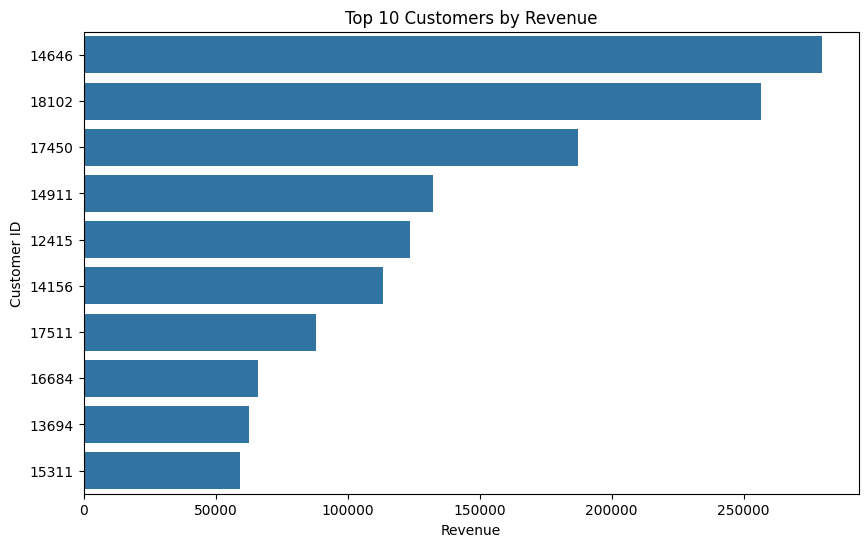

In [149]:
plt.figure(figsize=(10, 6))

sns.barplot(x=top_customers.values,y=top_customers.index.astype(str))

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.show()

## EDA Findings

### Key Findings

1. The dataset contains retail transaction-level information including
   products, quantities, prices, customers, dates, and countries.

2. Total sales were calculated using Quantity × UnitPrice.

3. The monthly sales analysis shows changes in sales performance
   over time and helps identify high-performing months.

4. A small number of countries contribute a large proportion of
   the total transaction volume and revenue.

5. A few products account for a significant share of total quantity sold.

6. The correlation analysis helps understand the relationship between
   quantity, unit price, and total sales.

7. Boxplots and IQR analysis identified extreme values in Quantity
   and UnitPrice.

8. Customer-level analysis helps identify customers contributing
   the highest revenue.

### Business Insights

- High-revenue products can be prioritized for inventory planning.
- High-value customers can be targeted through customer retention strategies.
- Monthly sales trends can help businesses plan inventory and marketing.
- Country-level sales analysis can support regional business decisions.
- Outlier transactions should be reviewed to determine whether they
  represent genuine bulk purchases or unusual transactions.